In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the  CSV
df = pd.read_csv(r"C:\task 3\data\user_behavior_dataset.csv")

# Display shape and first 5 rows
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (700, 11)


,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3


In [22]:
# Check unique values in 'User Behavior Class'
stages = df['User Behavior Class'].unique()
print("Detected funnel stages:", stages)

# Use the detected order as funnel stages
funnel_stages_order = list(stages)



Detected funnel stages: [4 3 2 5 1]


In [23]:
# Count unique users per stage
funnel_users = (
    df.groupby('User Behavior Class')['User ID']
    .nunique()
    .reset_index()
)

# Order stages according to detected funnel stages
funnel_users['User Behavior Class'] = pd.Categorical(
    funnel_users['User Behavior Class'],
    categories=funnel_stages_order,
    ordered=True
)

funnel_users = funnel_users.sort_values('User Behavior Class')

# Rename columns for clarity
funnel_users.rename(columns={'User Behavior Class': 'Stage', 'User ID': 'Users'}, inplace=True)

funnel_users



,Stage,Users
3,4,139
2,3,143
1,2,146
4,5,136
0,1,136


In [24]:
# Conversion rate from previous stage to current stage
funnel_users['conversion_rate_%'] = funnel_users['Users'].pct_change() * 100

# Drop-off users from previous stage
funnel_users['drop_off_users'] = funnel_users['Users'].shift(1) - funnel_users['Users']

funnel_users



,Stage,Users,conversion_rate_%,drop_off_users
3,4,139,NaN,NaN
2,3,143,2.877698,-4.0
1,2,146,2.097902,-3.0
4,5,136,-6.849315,10.0
0,1,136,0.000000,0.0


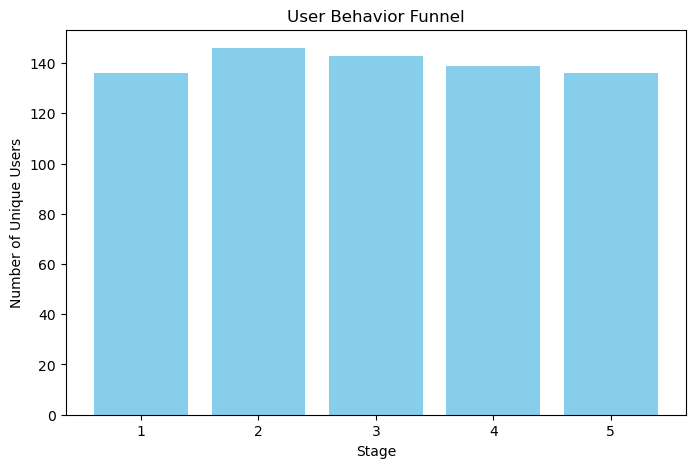

In [25]:
plt.figure(figsize=(8,5))
plt.bar(funnel_users['Stage'], funnel_users['Users'], color='skyblue')
plt.title("User Behavior Funnel")
plt.xlabel("Stage")
plt.ylabel("Number of Unique Users")
plt.show()
